# VIX추가 - 자산2개

In [1]:
# %%
# =============================================================================
# [Cell 18a] (신규) 📈 Mac 한글 폰트 깨짐 해결
# =============================================================================
# (그래프를 그리기 전에 이 셀을 먼저 실행해주세요)

import matplotlib.pyplot as plt

# 1. Mac에서 한글을 지원하는 'AppleGothic' 폰트로 설정
plt.rcParams['font.family'] = 'AppleGothic'

# 2. 폰트 변경 시 마이너스('-') 기호 깨지는 현상 해결
# (유니코드 마이너스 대신 일반 하이픈을 사용하도록 설정)
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트(AppleGothic) 및 마이너스 기호 설정이 완료되었습니다.")
print("이제 [Cell 19]와 [Cell 20]을 다시 실행하면 글꼴이 정상적으로 표시됩니다.")

한글 폰트(AppleGothic) 및 마이너스 기호 설정이 완료되었습니다.
이제 [Cell 19]와 [Cell 20]을 다시 실행하면 글꼴이 정상적으로 표시됩니다.


In [8]:
# %%
# =============================================================================
# [Cell 1] 
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pandas.tseries.offsets import BMonthEnd
from scipy.stats import zscore
from fredapi import Fred

# (경고 메시지 무시)
import warnings
warnings.filterwarnings('ignore')

# --- [0] 글로벌 세팅 ---

# 백테스트 기간
START_DATE = '2015-08-01'
END_DATE = '2025-11-28'  # <-- 이렇게 수정합니다.

# 사용 ETF 및 벤치마크
TICKERS = ['SHYG', 'IEF', 'SHY', 'TLT', 'AGG']
BENCHMARK = 'AGG'

# 거래 비용 (편도)
TRANSACTION_COSTS = {
    'SHYG': 0.003,  # 0.3%
    'IEF': 0.0015,  # 0.15%
    'SHY': 0.0015,
    'TLT': 0.0015,
    'AGG': 0.0015,
}

# 레짐별 타깃 포트폴리오 (섹션 5 기반)
# [수정안 3] 전반적으로 SHYG 비중을 대폭 상향 조정한 '초공격적' 안
# 목표: AGG의 크레딧 베타(0.26)를 초과하는 것
REGIME_ALLOCATIONS = {
    # 1: Very Risk-On (크레딧 위험 가장 낮음) -> SHYG 극대화 (Carry 극대화)
    1: {'SHYG': 0.85, 'IEF': 0.15}, 
    
    # 2: Risk-On (스프레드 축소 모멘텀) -> 모멘텀에 적극 편승
    2: {'SHYG': 0.60, 'IEF': 0.40}, 
    
    # 3: Risk-Off (스프레드 확대 모멘텀) -> 비중 축소, (수정안2의 25%보다 높게 유지)
    3: {'SHYG': 0.35, 'IEF': 0.65}, 
    
    # 4: Very Risk-Off (시장 공포) -> 공격적(Contrarian)으로 저가 매수 비중 유지
    4: {'SHYG': 0.15, 'IEF': 0.85}, 
}

# FRED API 키 (!!필수!!: 'YOUR_API_KEY_HERE'를 본인의 키로 변경)
FRED_API_KEY = 'f75d683dda2053416b64caae44e1bfb2' 

# 롤링 윈도우 설정
OAS_Z_WINDOW = 24  # 24개월 (모멘텀)
PPR_WINDOW = 60    # 60개월 (레벨)

print("셀 1: 기본 세팅 완료.")

# SSL 검증 비활성화
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

셀 1: 기본 세팅 완료.


In [ ]:
# [Cell 2] 데이터 로딩 함수 정의 (VIX 로더 추가)

def load_data(tickers, start, end):
    """yfinance에서 ETF 가격 데이터 로드"""
    print(f"Step: yfinance ETF 데이터 로딩 중... (Start: {start})")
    try:
        data = yf.download(tickers, start=start, end=end)['Close']
        monthly_prices = data.resample('BME').last()
        return monthly_prices
    except Exception as e:
        print(f"yfinance 데이터 로드 오류: {e}")
        return None

def load_external_data(fred_api_key, series_id, end_date):
    """FRED API를 통해 OAS 데이터 로드"""
    print(f"Step: FRED API에서 {series_id} 로딩 중...")
    try:
        fred = Fred(api_key=fred_api_key)
        fetch_start_date = (pd.to_datetime(end_date) - pd.DateOffset(years=5)).strftime('%Y-%m-%d')
        oas_series = fred.get_series(series_id, start_date=fetch_start_date, end_date=end_date)
        oas_series_bm = oas_series.resample('BME').last().ffill()
        oas_series_bm.name = 'OAS'
        print("OAS 데이터 로딩 및 월별 전처리 완료.")
        return oas_series_bm
    except Exception as e:
        print(f"FRED API 오류: {e}")
        return None

def load_vix_data(start, end):
    """yfinance에서 VIX 데이터 로드 (모멘텀 계산을 위해 3년치)"""
    print(f"Step: yfinance VIX (^VIX) 데이터 로딩 중... (Start: {start})")
    try:
        data = yf.download('^VIX', start=start, end=end)['Close']
        vix_series_bm = data.resample('BM').last().ffill()
        vix_series_bm.name = 'VIX'
        print("VIX 데이터 로딩 및 월별 전처리 완료.")
        return vix_series_bm
    except Exception as e:
        print(f"yfinance (VIX) 데이터 로드 오류: {e}")
        return None

print("셀 2: VIX 로드 함수 포함하여 정의 완료.")

셀 2: VIX 로드 함수 포함하여 정의 완료.


In [4]:
# [Cell 3] 헬퍼 함수 정의 (PPR 레벨 / VIX+OAS 하이브리드 모멘텀)

# --- [1] 레짐 분류 함수 (PPR / VIX+OAS Hybrid Momentum) ---

def calculate_hybrid_momentum_signal(oas_series, shyg_price_series, vix_series, 
                                     oas_z_window, level_window, mom_z_window):
    """
    (신규: PPR 레벨 50% + (OAS+VIX) 모멘텀 50%)
    1. OAS 모멘텀 (OAS_Z) 계산
    2. VIX 모멘텀 (VIX_Z) 계산
    3. Hybrid_Momentum (OAS_Z + VIX_Z) 계산
    4. PPR (SHYG 레벨) 계산 (기존 방식)
    """
    print(f"Step 3: 하이브리드 모멘텀 시그널 계산 중...")
    
    # 1. OAS_Z (OAS 모멘텀)
    oas_z = oas_series.rolling(window=oas_z_window).apply(
        lambda x: (x[-1] - x.mean()) / x.std() if len(x) == oas_z_window else np.nan,
        raw=False
    )
    
    # 2. VIX_Z (VIX 모멘텀)
    # VIX는 12개월(mom_z_window) Z-Score 사용
    vix_z = vix_series.rolling(window=mom_z_window).apply(
        lambda x: (x[-1] - x.mean()) / x.std() if len(x) == mom_z_window else np.nan,
        raw=False
    )
    
    # 3. Hybrid_Momentum (0.5 * OAS_Z + 0.5 * VIX_Z)
    hybrid_momentum = (0.5 * oas_z) + (0.5 * vix_z)
    
    # 4. PPR (SHYG 가격 레벨) - 기존 방식
    percentile_rank = shyg_price_series.rolling(window=level_window).rank(pct=True)
    ppr = 1.0 - percentile_rank

    signals = pd.DataFrame({
        'OAS_Z': np.squeeze(oas_z), 
        'VIX_Z': np.squeeze(vix_z),
        'Hybrid_Momentum': np.squeeze(hybrid_momentum),
        'PPR': np.squeeze(ppr)
    })
    
    signals = signals.dropna()
    print("PPR / VIX+OAS 하이브리드 모멘텀 시그널 생성 완료.")
    return signals

def define_hybrid_momentum_regime(row):
    """ (수정됨) PPR과 Hybrid_Momentum을 기준으로 4분면 정의 """
    ppr, hybrid_mom = row['PPR'], row['Hybrid_Momentum']
    
    if ppr < 0.2: return 1 # ① Very Risk-On (PPR 레벨 낮음)
    if ppr > 0.8: return 4 # ④ Very Risk-Off (PPR 레벨 높음)
    if 0.2 <= ppr <= 0.8 and hybrid_mom < 0: return 2 # ② Risk-On (중립 & 모멘텀 개선)
    if 0.2 <= ppr <= 0.8 and hybrid_mom >= 0: return 3 # ③ Risk-Off (중립 & 모멘텀 악화)
    return np.nan

# --- [2] 전략 구성 함수 (수정안 3 기준 - 기존과 동일) ---
def get_target_weights(regime_series):
    print("Step 4: 타깃 비중 생성 중... (수정안 3: SHYG, IEF)")
    target_weights = pd.DataFrame(index=regime_series.index, columns=['SHYG', 'IEF'])
    for regime, alloc in REGIME_ALLOCATIONS.items():
        mask = (regime_series == regime)
        target_weights.loc[mask] = [alloc['SHYG'], alloc['IEF']]
    target_weights = target_weights.ffill().dropna()
    return target_weights

# --- [3] 시각화 함수 (코드 2와 동일) ---
def plot_snapshot(target_allocation, latest_regime, latest_date):
    print("\n시각화 차트 생성 중...")
    labels = list(target_allocation.keys())
    sizes = list(target_allocation.values())
    
    regime_colors = {1: '#66b3ff', 2: '#99ff99', 3: '#ffcc99', 4: '#ff9999'}
    asset_colors = sns.color_palette('YlGnBu', len(labels))
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.pie(sizes, labels=labels, autopct='%1.0f%%', startangle=90, 
           colors=asset_colors, pctdistance=0.85, 
           wedgeprops=dict(width=0.3, edgecolor='w'),
           textprops={'fontsize': 12})
    
    centre_circle = plt.Circle((0,0), 0.65, fc=regime_colors.get(latest_regime, 'grey'))
    fig.gca().add_artist(centre_circle)
    
    plt.text(0, 0, f'Regime\n{int(latest_regime)}', 
             ha='center', va='center', fontsize=20, fontweight='bold')
    
    ax.set_title(f'Current Strategy Allocation (PPR / Hybrid Momentum)\nAs of {latest_date.strftime("%Y-%m-%d")}', 
                 fontsize=16, pad=20)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

print("셀 3: PPR / VIX+OAS 하이브리드 모멘텀 함수 정의 완료.")


# [Cell 3] 헬퍼 함수 정의

# --- [3] Regime 분류 함수 ---

def calculate_regime_signals(oas_series, shyg_price_series, oas_z_window, elp_window):
    """
    1. OAS 모멘텀 (OAS_Z) 계산
    2. SHYG 가격 기반 ELP_proxy (PPR로 사용) 계산
    """
    print(f"Step 3: 레짐 시그널 계산 중 (SHYG Price ELP_proxy {elp_window}M Window)...")
    
    # 1. OAS_Z (OAS 모멘텀)
    oas_z = oas_series.rolling(window=oas_z_window).apply(
        lambda x: (x[-1] - x.mean()) / x.std() if len(x) == oas_z_window else np.nan,
        raw=False
    )
    
    # 2. ELP_proxy (PPR 대체)
    percentile_rank = shyg_price_series.rolling(window=elp_window).rank(pct=True)
    elp_proxy = 1.0 - percentile_rank

    # [중요] np.squeeze()를 사용하여 1차원 배열로 변환 (ValueError 방지)
    signals = pd.DataFrame({
        'OAS_Z': np.squeeze(oas_z), 
        'PPR': np.squeeze(elp_proxy)
    })
    
    signals = signals.dropna()
    
    print("레짐 시그널 (OAS_Z + ELP_proxy as PPR) 생성 완료.")
    return signals

def define_regime(row):
    """ 레짐 정의 로직 """
    ppr, oas_z = row['PPR'], row['OAS_Z']
    if ppr < 0.2: return 1 # ① Very Risk-On
    if ppr > 0.8: return 4 # ④ Very Risk-Off
    if 0.2 <= ppr <= 0.8 and oas_z < 0: return 2 # ② Risk-On
    if 0.2 <= ppr <= 0.8 and oas_z >= 0: return 3 # ③ Risk-Off
    return np.nan

def generate_regime_timeseries(signals):
    regime_series = signals.apply(define_regime, axis=1)
    regime_series.name = 'Regime'
    return regime_series

print("셀 3: calculate_regime_signals 포함 헬퍼 함수 정의 완료.")

셀 3: PPR / VIX+OAS 하이브리드 모멘텀 함수 정의 완료.
셀 3: calculate_regime_signals 포함 헬퍼 함수 정의 완료.


In [13]:
import pandas as pd
import yfinance as yf
from fredapi import Fred
import datetime
import traceback

# [Cell 4] 최신 데이터 로드 (수정됨: 2015년부터 로드)

# --- 1. 기준 날짜 설정 (수정된 부분) ---
END_DATE_SNAPSHOT = pd.Timestamp.now().normalize()

# 시작 날짜를 2015년 1월 1일로 고정합니다.
FIXED_START_DATE = pd.Timestamp("2015-01-01")

# 롤링 윈도우 계산을 위해 데이터는 넉넉한 것이 좋으므로 모두 2015년부터 불러옵니다.
OAS_START_DATE_SNAPSHOT = FIXED_START_DATE
PRICE_START_DATE_SNAPSHOT = FIXED_START_DATE

print(f"데이터 기준일: {END_DATE_SNAPSHOT.date()}")
print(f"데이터 로드 시작일: {FIXED_START_DATE.date()}")

# --- 2. 데이터 로드 실행 ---
try:
    # FRED API 키 확인
    if 'FRED_API_KEY' not in locals():
        raise ValueError("FRED_API_KEY가 정의되지 않았습니다. [Cell 1]을 먼저 실행해주세요.")

    # 2a. FRED (OAS)
    fred = Fred(api_key=FRED_API_KEY)
    oas_series_raw = fred.get_series('BAMLH0A0HYM2', start_date=OAS_START_DATE_SNAPSHOT, end_date=END_DATE_SNAPSHOT)
    
    if oas_series_raw is None or oas_series_raw.empty:
        raise ValueError("FRED에서 OAS 데이터를 가져오지 못했습니다.")
        
    oas_series_bm = oas_series_raw.resample('BM').last().ffill()
    print(f"FRED (OAS) 데이터 로드 완료. (행 수: {len(oas_series_bm)})")

    # 2b. yfinance (SHYG Price)
    # 2015년부터 데이터 로드
    data_shyg = yf.download('SHYG', start=PRICE_START_DATE_SNAPSHOT, end=END_DATE_SNAPSHOT)
    
    if isinstance(data_shyg.columns, pd.MultiIndex):
        shyg_close = data_shyg['Close']['SHYG']
    else:
        shyg_close = data_shyg['Close']
        
    shyg_prices_raw = shyg_close.resample('BM').last().ffill()
    print(f"yfinance (SHYG) 데이터 로드 완료. (행 수: {len(shyg_prices_raw)})")
    
    # 2c. yfinance (VIX Price)
    # 2015년부터 데이터 로드
    data_vix = yf.download('^VIX', start=PRICE_START_DATE_SNAPSHOT, end=END_DATE_SNAPSHOT)
    
    if isinstance(data_vix.columns, pd.MultiIndex):
        vix_close = data_vix['Close']['^VIX']
    else:
        vix_close = data_vix['Close']

    vix_series_bm = vix_close.resample('BM').last().ffill()
    print(f"yfinance (VIX) 데이터 로드 완료. (행 수: {len(vix_series_bm)})")
    
except Exception as e:
    print(f"\n[오류 발생]: {e}")
    traceback.print_exc()

데이터 기준일: 2026-03-13
데이터 로드 시작일: 2015-01-01

[오류 발생]: Invalid frequency: BM. Failed to parse with error message: ValueError("'BM' is no longer supported for offsets. Please use 'BME' instead.")


Traceback (most recent call last):
  File "pandas/_libs/tslibs/offsets.pyx", line 6313, in pandas._libs.tslibs.offsets.to_offset
  File "pandas/_libs/tslibs/offsets.pyx", line 6180, in pandas._libs.tslibs.offsets._validate_to_offset_alias
ValueError: 'BM' is no longer supported for offsets. Please use 'BME' instead.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/var/folders/lc/pmkq_c356s77zlxfrvzzj5hw0000gp/T/ipykernel_50053/3549160745.py", line 35, in <module>
    oas_series_bm = oas_series_raw.resample('BM').last().ffill()
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/2ys/Desktop/KSIF/SAA/전략/바벨전략/.venv/lib/python3.11/site-packages/pandas/core/generic.py", line 9423, in resample
    return get_resampler(
           ^^^^^^^^^^^^^^
  File "/Users/2ys/Desktop/KSIF/SAA/전략/바벨전략/.venv/lib/python3.11/site-packages/pandas/core/resample.py", line 2334, in get_resampler
    tg = TimeGrouper(obj, **kwds

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 설정값 (수정안 3: SHYG/IEF) ---
REGIME_ALLOCATIONS_3 = {
    # 1: Very Risk-On
    1: {'SHYG': 0.85, 'IEF': 0.15}, 
    # 2: Risk-On
    2: {'SHYG': 0.60, 'IEF': 0.40}, 
    # 3: Risk-Off
    3: {'SHYG': 0.35, 'IEF': 0.65}, 
    # 4: Very Risk-Off
    4: {'SHYG': 0.15, 'IEF': 0.85}, 
}

# 거래 비용 (편도)
TRANSACTION_COSTS = {
    'SHYG': 0.003, 'IEF': 0.0015, 'SHY': 0.0015, 'TLT': 0.0015, 'AGG': 0.0015
}

# --- 2. 헬퍼 함수들 ---

def get_target_weights(regime_series, allocations):
    """레짐에 따른 타깃 비중 생성"""
    print("Step: 타깃 비중 생성 중...")
    # 자산 유니버스: SHYG, IEF (수정안 3 기준)
    target_weights = pd.DataFrame(index=regime_series.index, columns=['SHYG', 'IEF'])
    
    for regime, alloc in allocations.items():
        mask = (regime_series == regime)
        target_weights.loc[mask, 'SHYG'] = alloc.get('SHYG', 0.0)
        target_weights.loc[mask, 'IEF'] = alloc.get('IEF', 0.0)
        
    target_weights = target_weights.ffill().dropna()
    return target_weights

def run_backtest(monthly_returns, target_weights, costs):
    """백테스트 엔진"""
    print("Step: 백테스트 실행 중...")
    # t 시점의 시그널로 t+1 시점에 투자 (Shift 1)
    shifted_weights = target_weights.shift(1).dropna()
    
    # 기간 교집합 맞추기
    common_index = monthly_returns.index.intersection(shifted_weights.index)
    returns_slice = monthly_returns.loc[common_index]
    weights_slice = shifted_weights.loc[common_index]
    
    # 1. 총 수익률 (Gross Return)
    gross_returns = (returns_slice * weights_slice).sum(axis=1)
    
    # 2. 거래 비용 (Turnover * Cost)
    turnover = weights_slice.diff().abs().fillna(0)
    cost_drag = pd.Series(0.0, index=common_index)
    
    for asset in weights_slice.columns:
        if asset in costs:
            cost_drag += turnover[asset] * costs[asset]
            
    # 3. 순 수익률 (Net Return)
    net_returns = gross_returns - cost_drag
    net_returns.name = 'Strategy'
    
    print(f"백테스트 완료. (기간: {common_index[0].date()} ~ {common_index[-1].date()})")
    return net_returns, weights_slice

# --- 3. 성과 지표 계산 함수 ---

def calculate_metrics(returns_series):
    """CAGR, MDD, Sharpe, Volatility 계산"""
    if len(returns_series) < 1: return {}
    
    # CAGR
    total_ret = (1 + returns_series).prod() - 1
    years = len(returns_series) / 12
    cagr = (1 + total_ret) ** (1 / years) - 1
    
    # MDD
    cum_ret = (1 + returns_series).cumprod()
    peak = cum_ret.expanding(min_periods=1).max()
    drawdown = (cum_ret - peak) / peak
    mdd = drawdown.min()
    
    # Volatility (Annualized)
    vol = returns_series.std() * np.sqrt(12)
    
    # Sharpe Ratio (Risk Free = 0 가정)
    sharpe = (returns_series.mean() / returns_series.std()) * np.sqrt(12) if returns_series.std() != 0 else 0
    
    return {
        'CAGR': cagr,
        'MDD': mdd,
        'Volatility': vol,
        'Sharpe': sharpe
    }

print("셀 5: 전략 및 백테스트 함수 정의 완료.")

셀 5: 전략 및 백테스트 함수 정의 완료.


In [7]:
# [Cell 6] 백테스트 실행

# 1. IEF, AGG 등 추가 데이터 로드 (수익률 계산용)
# (이미 Cell 4에서 SHYG는 로드했으므로 나머지 자산 로드)
try:
    print("추가 자산(IEF, AGG) 데이터 로드 중...")
    # 기간은 Cell 4와 동일하게
    f_start = PRICE_START_DATE_SNAPSHOT 
    f_end = END_DATE_SNAPSHOT
    
    # 필요한 자산들 한번에 로드
    tickers = ['IEF', 'AGG']
    data_others = yf.download(tickers, start=f_start, end=f_end)['Close']
    
    # 월말 리샘플링
    prices_others = data_others.resample('BM').last().ffill()
    
    # 모든 가격 데이터 병합 (SHYG 포함)
    # shyg_prices_raw는 Cell 4에서 이미 로드됨 (Series 형태일 수 있으므로 DataFrame으로 변환)
    if isinstance(shyg_prices_raw, pd.Series):
        shyg_df = shyg_prices_raw.to_frame('SHYG')
    else:
        shyg_df = shyg_prices_raw

    all_prices = pd.concat([shyg_df, prices_others], axis=1)
    
    # 월별 수익률 계산
    monthly_returns = all_prices.pct_change().dropna()
    print("월별 수익률 계산 완료.")

    # 2. 시그널 및 레짐 산출 (수정된 함수 사용)
    # (Cell 3의 calculate_regime_signals 함수 사용)
    signals_df = calculate_regime_signals(
        oas_series_bm, 
        all_prices['SHYG'], 
        oas_z_window=24, 
        elp_window=12
    )
    
    # 레짐 매핑
    regime_series = signals_df.apply(define_regime, axis=1).dropna()
    
    # 3. 타깃 비중 생성 (수정안 3)
    target_w = get_target_weights(regime_series, REGIME_ALLOCATIONS_3)
    
    # 4. 백테스트 수행
    strat_ret, strat_w = run_backtest(monthly_returns, target_w, TRANSACTION_COSTS)
    
    # 벤치마크(AGG) 수익률 추출 (기간 맞춤)
    bench_ret = monthly_returns['AGG'].loc[strat_ret.index]

except Exception as e:
    print(f"백테스트 실행 중 오류 발생: {e}")
    import traceback
    traceback.print_exc()

추가 자산(IEF, AGG) 데이터 로드 중...


[*********************100%***********************]  2 of 2 completed

월별 수익률 계산 완료.
Step 3: 레짐 시그널 계산 중 (SHYG Price ELP_proxy 12M Window)...
레짐 시그널 (OAS_Z + ELP_proxy as PPR) 생성 완료.
Step: 타깃 비중 생성 중...
Step: 백테스트 실행 중...
백테스트 완료. (기간: 2016-01-29 ~ 2025-11-28)


In [25]:
# [Cell 6] 최신 스냅샷 확인 (하이브리드 모멘텀)

if not signals_raw_hybrid.empty:
    latest_snapshot = signals_raw_hybrid.iloc[-1]
    latest_date = latest_snapshot.name
    latest_regime = int(latest_snapshot['Regime'])
    
    # [Cell 1]에서 정의한 REGIME_ALLOCATIONS (수정안 3) 사용
    target_allocation = REGIME_ALLOCATIONS[latest_regime]

    print("\n" + "="*40)
    print(f"      최신 스냅샷 (PPR / Hybrid Momentum)      ")
    print("="*40)
    print(f"데이터 기준일: {latest_date.strftime('%Y-%m-%d')}")
    print("-" * 40)
    print(f"PPR (SHYG 레벨): {latest_snapshot['PPR']:.4f}")
    print(f"OAS_Z (모멘텀 1): {latest_snapshot['OAS_Z']:.4f}")
    print(f"VIX_Z (모멘텀 2): {latest_snapshot['VIX_Z']:.4f}")
    print(f"-> Hybrid_Momentum (0.5+0.5): {latest_snapshot['Hybrid_Momentum']:.4f}")
    print(f"-> 현재 레짐 (4분류): {latest_regime}")
    print("\n" + "--- 목표 포트폴리오 비중 (수정안 3) ---")
    print(f"SHYG: {target_allocation['SHYG']:.0%}")
    print(f"IEF:  {target_allocation['IEF']:.0%}")
else:
    print("시그널을 계산하기에 데이터가 충분하지 않습니다.")

NameError: name 'signals_raw_hybrid' is not defined

In [7]:
# [Cell 7] 성과 요약 및 시각화

if 'strat_ret' in locals() and 'bench_ret' in locals():
    
    # --- 1. 성과 지표 테이블 ---
     strat_metrics = calculate_metrics(strat_ret)
     bench_metrics = calculate_metrics(bench_ret)
    
     summary_df = pd.DataFrame({
         'Strategy (수정안 3)': strat_metrics,
         'Benchmark (AGG)': bench_metrics
     })
    
     # 포맷팅
     print("\n" + "="*40)
     print("      <<< 백테스트 성과 요약 >>>")
     print("="*40)
     print(summary_df.applymap(lambda x: f"{x:.2%}" if isinstance(x, (int, float)) and abs(x) < 10 else f"{x:.2f}"))
    
    # --- 2. 누적 수익률 그래프 ---
     plt.figure(figsize=(12, 6))
    
     # 누적 수익률 계산 (100에서 시작)
     strat_cum = (1 + strat_ret).cumprod() * 100
     bench_cum = (1 + bench_ret).cumprod() * 100
    
     plt.plot(strat_cum, label='Strategy (Amendment 3)', color='blue', linewidth=2)
     plt.plot(bench_cum, label='Benchmark (AGG)', color='gray', linestyle='--')
    
     plt.title('Strategy vs Benchmark Cumulative Returns (2015-Present)', fontsize=16)
     plt.ylabel('Portfolio Value (Start=100)')
     plt.grid(True, alpha=0.3)
     plt.legend()
     
     # MDD 구간 표시 (선택 사항)
     # plt.fill_between(strat_cum.index, strat_cum, strat_cum.cummax(), color='red', alpha=0.1, label='Drawdown')
    
     plt.tight_layout()
     plt.savefig('backtest_performance.png')
     plt.show()
     
else:
    print("결과를 출력할 데이터가 없습니다. [Cell 6]을 먼저 실행해주세요.")

결과를 출력할 데이터가 없습니다. [Cell 6]을 먼저 실행해주세요.


In [10]:
# [Cell 7] 스냅샷 시각화 (하이브리드 모멘텀)

if 'target_allocation' in locals():
    # [Cell 3]에서 정의한 시각화 함수 호출
    plot_snapshot(target_allocation, latest_regime, latest_date)
else:
    print("시각화를 위해 [Cell 6]을 먼저 실행하여 'target_allocation'을 생성해야 합니다.")

시각화를 위해 [Cell 6]을 먼저 실행하여 'target_allocation'을 생성해야 합니다.


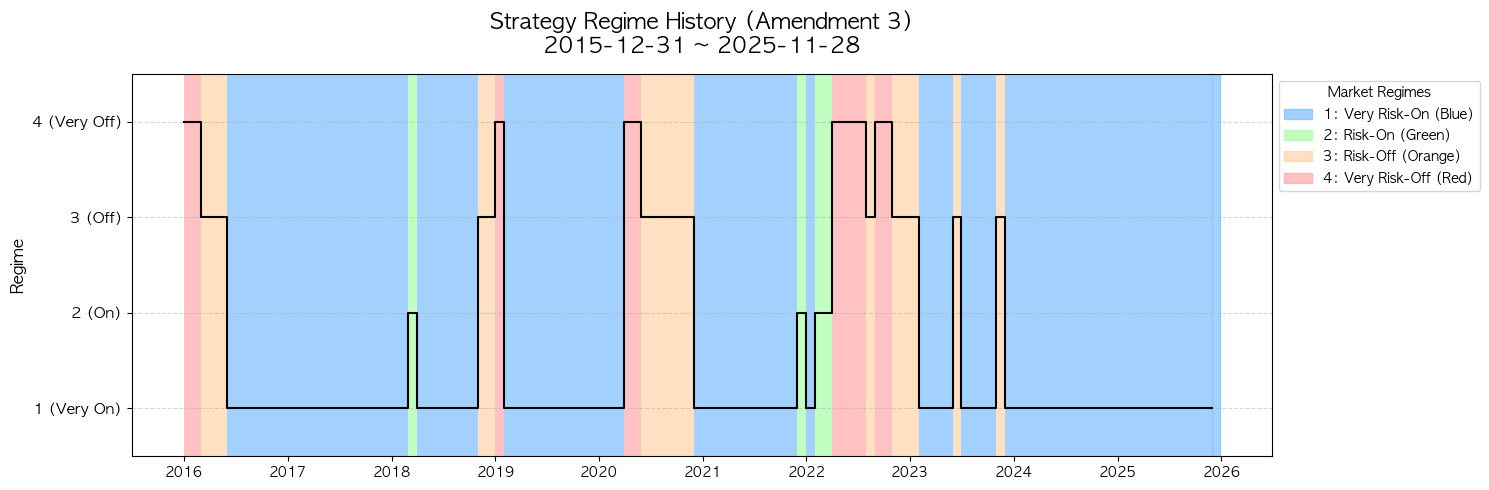


      <<< 레짐별 기간 분포 >>>
Regime 1:  88개월 (73.3%) - 1: Very Risk-On (Blue)
Regime 2:   4개월 (3.3%) - 2: Risk-On (Green)
Regime 3:  17개월 (14.2%) - 3: Risk-Off (Orange)
Regime 4:  11개월 (9.2%) - 4: Very Risk-Off (Red)


In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# [Cell 8] 월별 레짐 타임라인 시각화

if 'regime_series' in locals():
    
    # 1. 시각화 설정
    fig, ax = plt.subplots(figsize=(15, 5))
    
    # 레짐별 색상 및 라벨 정의
    regime_props = {
        1: {'color': '#66b3ff', 'label': '1: Very Risk-On (Blue)'},   # 파랑
        2: {'color': '#99ff99', 'label': '2: Risk-On (Green)'},       # 초록
        3: {'color': '#ffcc99', 'label': '3: Risk-Off (Orange)'},     # 주황
        4: {'color': '#ff9999', 'label': '4: Very Risk-Off (Red)'}    # 빨강
    }
    
    # 2. 레짐 타임라인 그리기 (배경색 채우기)
    # (t 시점의 시그널은 t ~ t+1 기간의 포지션을 결정하므로 해당 구간을 칠합니다)
    dates = regime_series.index
    
    for i in range(len(dates) - 1):
        current_date = dates[i]
        next_date = dates[i+1]
        regime = int(regime_series.iloc[i])
        
        # 해당 구간을 레짐 색상으로 칠하기
        ax.axvspan(current_date, next_date, 
                   color=regime_props[regime]['color'], 
                   alpha=0.6, # 투명도
                   ec=None)   # 테두리 없음

    # 마지막 구간 처리 (한 달 더 연장)
    last_date = dates[-1]
    extended_date = last_date + pd.DateOffset(months=1)
    last_regime = int(regime_series.iloc[-1])
    ax.axvspan(last_date, extended_date, color=regime_props[last_regime]['color'], alpha=0.6)

    # 3. 레짐 스텝 차트 (선 그래프) 추가
    ax.step(regime_series.index, regime_series, where='post', color='black', linewidth=1.5, label='Regime Level')
    
    # 4. 차트 꾸미기
    ax.set_title(f'Strategy Regime History (Amendment 3)\n{dates[0].date()} ~ {dates[-1].date()}', fontsize=16, pad=15)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(['1 (Very On)', '2 (On)', '3 (Off)', '4 (Very Off)'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Regime', fontsize=12)
    ax.set_ylim(0.5, 4.5)
    
    # X축 날짜 포맷
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 범례 생성 (색상 설명)
    patches = [plt.Rectangle((0,0),1,1, color=props['color'], alpha=0.6) for props in regime_props.values()]
    labels = [props['label'] for props in regime_props.values()]
    ax.legend(patches, labels, loc='upper left', bbox_to_anchor=(1, 1), title="Market Regimes")

    plt.tight_layout()
    plt.savefig('regime_timeline.png') # 이미지 저장
    plt.show()
    
    # --- 5. 레짐 분포 통계 ---
    print("\n" + "="*40)
    print("      <<< 레짐별 기간 분포 >>>")
    print("="*40)
    counts = regime_series.value_counts().sort_index()
    total_months = len(regime_series)
    
    for r in range(1, 5):
        count = counts.get(r, 0)
        ratio = count / total_months
        print(f"Regime {r}: {count:3d}개월 ({ratio:.1%}) - {regime_props[r]['label']}")

else:
    print("오류: 'regime_series' 데이터가 없습니다. [Cell 6]를 먼저 실행해주세요.")

# TLT 추가
- 4초위험회피 : 15% /80% /5% / IEF 85% → IEF 80% / TLT 5%

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. 설정값 수정 (레짐 4에 TLT 5% 추가) ---
REGIME_ALLOCATIONS_MODIFIED = {
    # 1: Very Risk-On
    1: {'SHYG': 0.85, 'IEF': 0.15, 'TLT': 0.0}, 
    # 2: Risk-On
    2: {'SHYG': 0.60, 'IEF': 0.40, 'TLT': 0.0}, 
    # 3: Risk-Off
    3: {'SHYG': 0.35, 'IEF': 0.65, 'TLT': 0.0}, 
    # 4: Very Risk-Off (수정됨: TLT 5% 추가)
    4: {'SHYG': 0.15, 'IEF': 0.80, 'TLT': 0.05}, 
}

# 거래 비용 (편도)
TRANSACTION_COSTS = {
    'SHYG': 0.003, 'IEF': 0.0015, 'SHY': 0.0015, 'TLT': 0.0015, 'AGG': 0.0015
}

# --- 2. 헬퍼 함수들 (3개 자산 지원) ---

def get_target_weights(regime_series, allocations):
    """레짐에 따른 타깃 비중 생성 (3개 자산)"""
    print("Step: 타깃 비중 생성 중... (SHYG, IEF, TLT)")
    target_weights = pd.DataFrame(index=regime_series.index, columns=['SHYG', 'IEF', 'TLT'])
    
    for regime, alloc in allocations.items():
        mask = (regime_series == regime)
        target_weights.loc[mask, 'SHYG'] = alloc.get('SHYG', 0.0)
        target_weights.loc[mask, 'IEF'] = alloc.get('IEF', 0.0)
        target_weights.loc[mask, 'TLT'] = alloc.get('TLT', 0.0)
        
    target_weights = target_weights.ffill().dropna()
    return target_weights

def run_backtest(monthly_returns, target_weights, costs):
    """백테스트 엔진"""
    print("Step: 백테스트 실행 중...")
    # t 시점의 시그널로 t+1 시점에 투자 (Shift 1)
    shifted_weights = target_weights.shift(1).dropna()
    
    # 기간 교집합 맞추기
    common_index = monthly_returns.index.intersection(shifted_weights.index)
    returns_slice = monthly_returns.loc[common_index]
    weights_slice = shifted_weights.loc[common_index]
    
    # 1. 총 수익률 (Gross Return)
    # (returns_slice에 TLT 컬럼이 없으면 NaN이 발생할 수 있으므로 필터링)
    available_assets = [col for col in weights_slice.columns if col in returns_slice.columns]
    gross_returns = (returns_slice[available_assets] * weights_slice[available_assets]).sum(axis=1)
    
    # 2. 거래 비용
    turnover = weights_slice.diff().abs().fillna(0)
    cost_drag = pd.Series(0.0, index=common_index)
    
    for asset in weights_slice.columns:
        if asset in costs:
            cost_drag += turnover[asset] * costs[asset]
            
    # 3. 순 수익률
    net_returns = gross_returns - cost_drag
    net_returns.name = 'Strategy'
    
    print(f"백테스트 완료. (기간: {common_index[0].date()} ~ {common_index[-1].date()})")
    return net_returns, weights_slice

def calculate_metrics(returns_series):
    """성과 지표 계산 함수 (기존 동일)"""
    if len(returns_series) < 1: return {}
    total_ret = (1 + returns_series).prod() - 1
    years = len(returns_series) / 12
    cagr = (1 + total_ret) ** (1 / years) - 1
    cum_ret = (1 + returns_series).cumprod()
    peak = cum_ret.expanding(min_periods=1).max()
    drawdown = (cum_ret - peak) / peak
    mdd = drawdown.min()
    vol = returns_series.std() * np.sqrt(12)
    sharpe = (returns_series.mean() / returns_series.std()) * np.sqrt(12) if returns_series.std() != 0 else 0
    return {'CAGR': cagr, 'MDD': mdd, 'Volatility': vol, 'Sharpe': sharpe}

print("셀 5: 전략 설정(TLT 5% 추가) 및 함수 재정의 완료.")

셀 5: 전략 설정(TLT 5% 추가) 및 함수 재정의 완료.


In [13]:
# [Cell 6] 백테스트 실행

try:
    print("추가 자산(IEF, AGG, TLT) 데이터 로드 중...")
    # 기간은 Cell 4와 동일하게
    f_start = PRICE_START_DATE_SNAPSHOT 
    f_end = END_DATE_SNAPSHOT
    
    # 필요한 자산들 로드 (TLT 추가)
    tickers = ['IEF', 'AGG', 'TLT']
    data_others = yf.download(tickers, start=f_start, end=f_end)['Close']
    
    # 월말 리샘플링
    prices_others = data_others.resample('BM').last().ffill()
    
    # SHYG 데이터 처리 (Series -> DataFrame)
    if isinstance(shyg_prices_raw, pd.Series):
        shyg_df = shyg_prices_raw.to_frame('SHYG')
    else:
        shyg_df = shyg_prices_raw

    # 모든 가격 데이터 병합
    all_prices = pd.concat([shyg_df, prices_others], axis=1)
    
    # 월별 수익률 계산
    monthly_returns = all_prices.pct_change().dropna()
    print("월별 수익률 계산 완료.")

    # 2. 시그널 및 레짐 산출 (Cell 3의 함수 사용)
    signals_df = calculate_regime_signals(
        oas_series_bm, 
        all_prices['SHYG'], 
        oas_z_window=24, 
        elp_window=12
    )
    
    # 레짐 매핑
    regime_series = signals_df.apply(define_regime, axis=1).dropna()
    
    # 3. 타깃 비중 생성 (수정된 설정 사용)
    target_w = get_target_weights(regime_series, REGIME_ALLOCATIONS_MODIFIED)
    
    # 4. 백테스트 수행
    strat_ret, strat_w = run_backtest(monthly_returns, target_w, TRANSACTION_COSTS)
    
    # 벤치마크(AGG) 수익률 추출
    bench_ret = monthly_returns['AGG'].loc[strat_ret.index]

except Exception as e:
    print(f"백테스트 실행 중 오류 발생: {e}")
    import traceback
    traceback.print_exc()

추가 자산(IEF, AGG, TLT) 데이터 로드 중...


[*********************100%***********************]  3 of 3 completed

월별 수익률 계산 완료.
Step 3: 레짐 시그널 계산 중 (SHYG Price ELP_proxy 12M Window)...
레짐 시그널 (OAS_Z + ELP_proxy as PPR) 생성 완료.
Step: 타깃 비중 생성 중... (SHYG, IEF, TLT)
Step: 백테스트 실행 중...
백테스트 완료. (기간: 2016-01-29 ~ 2025-11-28)



      <<< 백테스트 성과 요약 (TLT 5% 추가) >>>
           Strategy (TLT 5% Mix) Benchmark (AGG)
CAGR                       2.99%           1.94%
MDD                      -16.23%         -17.13%
Volatility                 5.10%           5.15%
Sharpe                    60.39%          39.96%


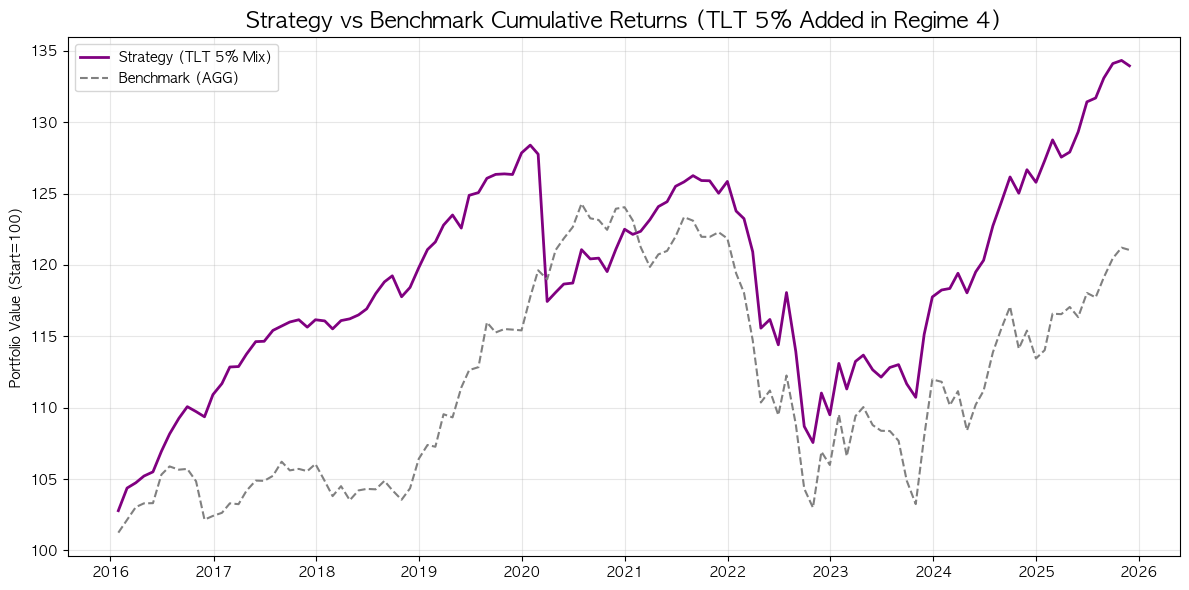


[확인] 마지막 달 (2025-11-28) 포트폴리오 비중:
SHYG    0.85
IEF     0.15
TLT     0.00
Name: 2025-11-28 00:00:00, dtype: float64


In [14]:
# [Cell 7] 성과 요약 및 시각화

if 'strat_ret' in locals() and 'bench_ret' in locals():
    
    # --- 1. 성과 지표 테이블 ---
     strat_metrics = calculate_metrics(strat_ret)
     bench_metrics = calculate_metrics(bench_ret)
    
     summary_df = pd.DataFrame({
         'Strategy (TLT 5% Mix)': strat_metrics,
         'Benchmark (AGG)': bench_metrics
     })
    
     print("\n" + "="*40)
     print("      <<< 백테스트 성과 요약 (TLT 5% 추가) >>>")
     print("="*40)
     print(summary_df.applymap(lambda x: f"{x:.2%}" if isinstance(x, (int, float)) and abs(x) < 10 else f"{x:.2f}"))
    
    # --- 2. 누적 수익률 그래프 ---
     plt.figure(figsize=(12, 6))
    
     strat_cum = (1 + strat_ret).cumprod() * 100
     bench_cum = (1 + bench_ret).cumprod() * 100
    
     plt.plot(strat_cum, label='Strategy (TLT 5% Mix)', color='purple', linewidth=2)
     plt.plot(bench_cum, label='Benchmark (AGG)', color='gray', linestyle='--')
    
     plt.title('Strategy vs Benchmark Cumulative Returns (TLT 5% Added in Regime 4)', fontsize=16)
     plt.ylabel('Portfolio Value (Start=100)')
     plt.grid(True, alpha=0.3)
     plt.legend()
     
     plt.tight_layout()
     plt.show()
     
     # --- 3. 레짐별 비중 확인 (마지막 달 기준) ---
     last_date = strat_w.index[-1]
     last_weights = strat_w.iloc[-1]
     print(f"\n[확인] 마지막 달 ({last_date.date()}) 포트폴리오 비중:")
     print(last_weights)

else:
    print("결과를 출력할 데이터가 없습니다. [Cell 6]을 먼저 실행해주세요.")

In [15]:
# [Cell 9] 월별 상세 내역 Excel 저장 (레짐, 비중, 수익률)

if 'strat_ret' in locals() and 'regime_series' in locals() and 'strat_w' in locals():
    
    print("월별 상세 데이터 생성 중...")
    
    # 1. 데이터 병합을 위한 인덱스 정렬
    # (모든 데이터는 월말 기준이므로 인덱스가 같아야 함)
    common_idx = strat_ret.index.intersection(regime_series.index).intersection(strat_w.index)
    
    # 2. 데이터프레임 생성
    # - 날짜 (인덱스)
    # - Regime: 해당 월의 시장 레짐
    # - Weight_SHYG, Weight_IEF, Weight_TLT: 해당 월 초에 진입한 포지션 비중
    # - Monthly_Return: 해당 월의 전략 수익률
    
    monthly_details = pd.DataFrame(index=common_idx)
    
    # 레짐 정보 추가 (직전 달의 시그널로 결정된 레짐이 이번 달 수익률에 영향)
    # 주의: regime_series는 시그널 발생 시점(t) 기준이므로, 수익률 시점(t+1)과 맞추려면 shift(1) 해야 함
    # 하지만 여기서는 '해당 월 수익률이 발생했을 때의 레짐'을 보여주기 위해 shift(1)된 값을 사용합니다.
    monthly_details['Regime'] = regime_series.shift(1).loc[common_idx]
    
    # 투자 비중 추가 (이미 shift 되어 있는 strat_w 사용)
    # (strat_w는 t시점에 투자한 비중이므로 t월 수익률과 매칭됨)
    monthly_details['Weight_SHYG'] = strat_w.loc[common_idx, 'SHYG']
    monthly_details['Weight_IEF'] = strat_w.loc[common_idx, 'IEF']
    
    # TLT 컬럼이 있으면 추가, 없으면 0으로 채움
    if 'TLT' in strat_w.columns:
        monthly_details['Weight_TLT'] = strat_w.loc[common_idx, 'TLT']
    else:
        monthly_details['Weight_TLT'] = 0.0

    # 월별 수익률 추가
    monthly_details['Monthly_Return'] = strat_ret.loc[common_idx]
    
    # 3. 가독성을 위한 포맷팅 및 정리
    # (NaN 제거: 첫 달은 shift로 인해 데이터가 없을 수 있음)
    monthly_details = monthly_details.dropna()
    
    # 레짐을 정수로 변환
    monthly_details['Regime'] = monthly_details['Regime'].astype(int)
    
    # 4. Excel로 저장
    file_name = 'strategy_monthly_details.xlsx'
    try:
        monthly_details.to_excel(file_name)
        print(f"\n[완료] 월별 상세 내역이 '{file_name}' 파일로 저장되었습니다.")
        
        # 5. 데이터 미리보기 (상위 5행)
        print("\n--- [미리보기] 저장된 데이터 (상위 5행) ---")
        # 보기 좋게 포맷팅하여 출력
        display_df = monthly_details.copy()
        display_df['Monthly_Return'] = display_df['Monthly_Return'].apply(lambda x: f"{x:.2%}")
        display_df['Weight_SHYG'] = display_df['Weight_SHYG'].apply(lambda x: f"{x:.0%}")
        display_df['Weight_IEF'] = display_df['Weight_IEF'].apply(lambda x: f"{x:.0%}")
        display_df['Weight_TLT'] = display_df['Weight_TLT'].apply(lambda x: f"{x:.0%}")
        print(display_df.head())
        
    except Exception as e:
        print(f"Excel 저장 중 오류 발생: {e}")
        
else:
    print("오류: 필수 데이터(strat_ret, regime_series, strat_w)가 없습니다. [Cell 6]를 먼저 실행해주세요.")

월별 상세 데이터 생성 중...

[완료] 월별 상세 내역이 'strategy_monthly_details.xlsx' 파일로 저장되었습니다.

--- [미리보기] 저장된 데이터 (상위 5행) ---
            Regime Weight_SHYG Weight_IEF Weight_TLT Monthly_Return
2016-01-29       4         15%        80%         5%          2.78%
2016-02-29       4         15%        80%         5%          1.54%
2016-03-31       3         35%        65%         0%          0.36%
2016-04-29       3         35%        65%         0%          0.45%
2016-05-31       3         35%        65%         0%          0.28%


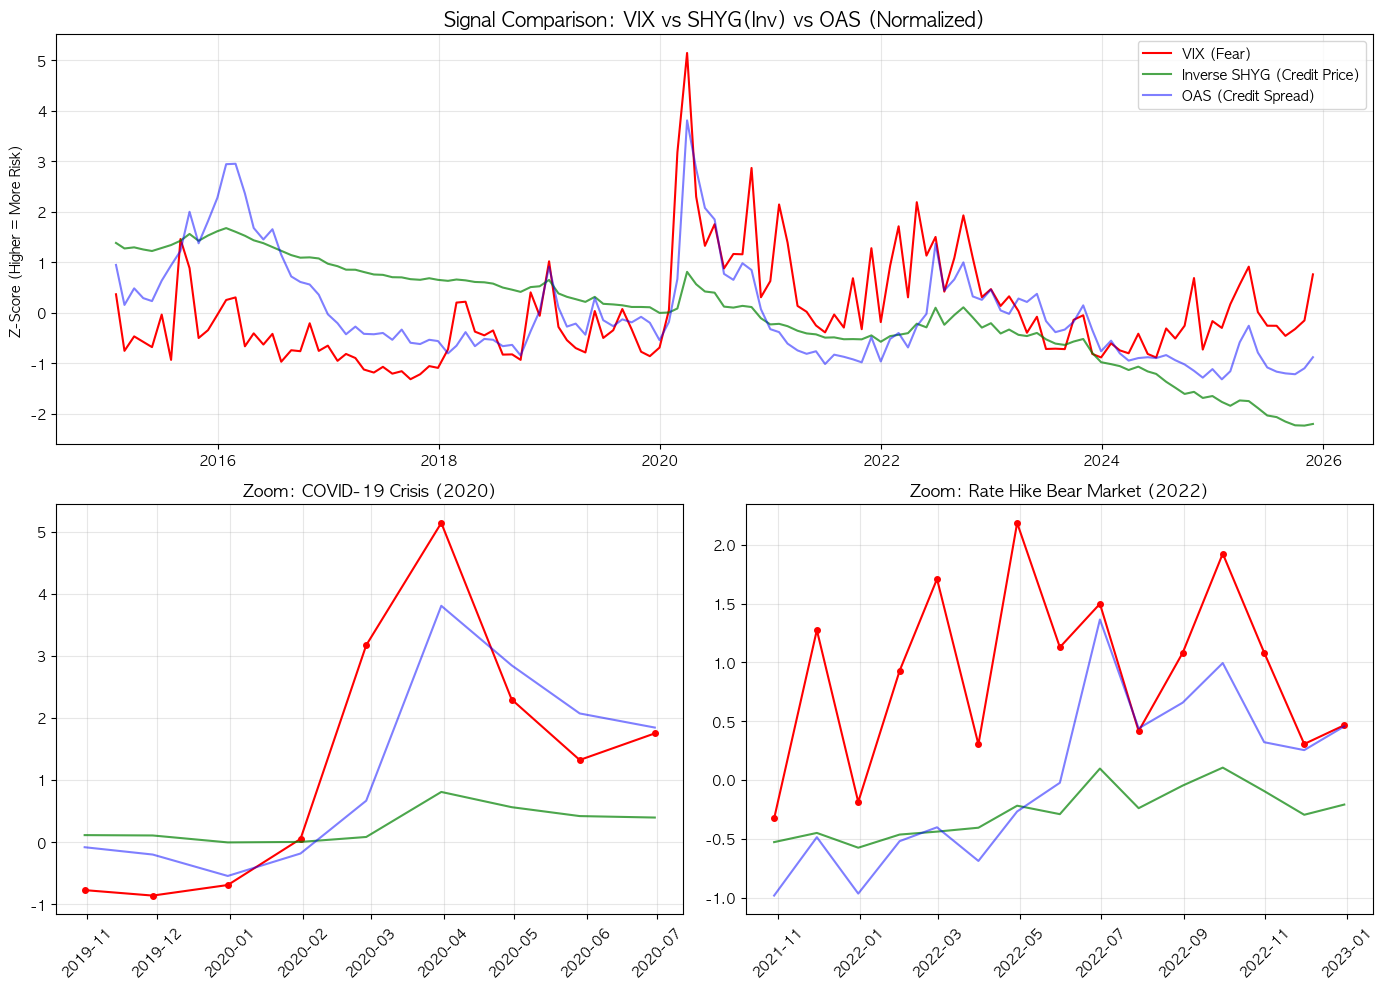


      <<< 시그널 선행성 분석 (Cross-Correlation) >>>
기준: VIX (VIX가 t월일 때, 대상 지표는 t+lag월)
(양수 Lag에서 상관계수가 높으면 VIX가 선행하는 것임)

Lag 0개월: SHYG와의 상관계수 -0.056 | OAS와의 상관계수 0.425
Lag 1개월: SHYG와의 상관계수 -0.116 | OAS와의 상관계수 0.215
Lag 2개월: SHYG와의 상관계수 -0.137 | OAS와의 상관계수 0.116
Lag 3개월: SHYG와의 상관계수 -0.145 | OAS와의 상관계수 0.080


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import correlate

# [Cell 10] VIX의 선행성 분석 및 시각화

if 'vix_series_bm' in locals() and 'shyg_prices_raw' in locals() and 'oas_series_bm' in locals():
    
    # 1. 데이터 전처리 (비교를 위해 표준화)
    # - 날짜 인덱스 통일
    common_idx = vix_series_bm.index.intersection(shyg_prices_raw.index).intersection(oas_series_bm.index)
    
    df_comp = pd.DataFrame(index=common_idx)
    df_comp['VIX'] = vix_series_bm.loc[common_idx]
    
    # SHYG는 가격이므로 '하락'이 위험 -> 역수(-1)를 취해 '상승'이 위험이 되도록 변환 (비교 용이성)
    # (가격이 떨어지면 위험 지표는 올라가는 것으로 통일)
    df_comp['Inv_SHYG'] = -1 * shyg_prices_raw.loc[common_idx] 
    
    df_comp['OAS'] = oas_series_bm.loc[common_idx]

    # Z-Score로 정규화 (스케일 통일)
    df_z = (df_comp - df_comp.mean()) / df_comp.std()
    
    # 2. 전체 기간 시각화
    plt.figure(figsize=(14, 10))
    
    # (1) 전체 시계열 비교
    plt.subplot(2, 1, 1)
    plt.plot(df_z.index, df_z['VIX'], label='VIX (Fear)', color='red', linewidth=1.5)
    plt.plot(df_z.index, df_z['Inv_SHYG'], label='Inverse SHYG (Credit Price)', color='green', linewidth=1.5, alpha=0.7)
    plt.plot(df_z.index, df_z['OAS'], label='OAS (Credit Spread)', color='blue', linewidth=1.5, alpha=0.5)
    
    plt.title('Signal Comparison: VIX vs SHYG(Inv) vs OAS (Normalized)', fontsize=14)
    plt.ylabel('Z-Score (Higher = More Risk)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # (2) 위기 구간 확대 (Zoom-in) - 2020년 코로나
    # (VIX가 얼마나 빨리 반응했는지 확인)
    plt.subplot(2, 2, 3)
    zoom_start = '2019-10-01'
    zoom_end = '2020-06-30'
    df_zoom = df_z.loc[zoom_start:zoom_end]
    
    plt.plot(df_zoom.index, df_zoom['VIX'], label='VIX', color='red', marker='o', markersize=4)
    plt.plot(df_zoom.index, df_zoom['Inv_SHYG'], label='Inv_SHYG', color='green', alpha=0.7)
    plt.plot(df_zoom.index, df_zoom['OAS'], label='OAS', color='blue', alpha=0.5)
    
    plt.title('Zoom: COVID-19 Crisis (2020)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    # (3) 위기 구간 확대 (Zoom-in) - 2022년 금리 인상기
    # (금리 충격과 신용 충격의 차이 확인)
    plt.subplot(2, 2, 4)
    zoom_start2 = '2021-10-01'
    zoom_end2 = '2022-12-31'
    df_zoom2 = df_z.loc[zoom_start2:zoom_end2]
    
    plt.plot(df_zoom2.index, df_zoom2['VIX'], label='VIX', color='red', marker='o', markersize=4)
    plt.plot(df_zoom2.index, df_zoom2['Inv_SHYG'], label='Inv_SHYG', color='green', alpha=0.7)
    plt.plot(df_zoom2.index, df_zoom2['OAS'], label='OAS', color='blue', alpha=0.5)
    
    plt.title('Zoom: Rate Hike Bear Market (2022)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('signal_comparison_vix.png')
    plt.show()

    # 3. 시차 상관관계 (Lag Correlation) 분석
    # VIX가 OAS보다 얼마나 앞서는지(Lead) 통계적으로 확인
    def cross_corr(x, y, lag=0):
        return x.corr(y.shift(lag))

    print("\n" + "="*40)
    print("      <<< 시그널 선행성 분석 (Cross-Correlation) >>>")
    print("="*40)
    print("기준: VIX (VIX가 t월일 때, 대상 지표는 t+lag월)")
    print("(양수 Lag에서 상관계수가 높으면 VIX가 선행하는 것임)\n")
    
    for lag in [0, 1, 2, 3]:
        corr_shyg = cross_corr(df_comp['VIX'], df_comp['Inv_SHYG'], lag)
        corr_oas = cross_corr(df_comp['VIX'], df_comp['OAS'], lag)
        print(f"Lag {lag}개월: SHYG와의 상관계수 {corr_shyg:.3f} | OAS와의 상관계수 {corr_oas:.3f}")

else:
    print("오류: 데이터(vix_series_bm 등)가 로드되지 않았습니다. [Cell 4]를 먼저 실행해주세요.")

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [Cell 3] 헬퍼 함수 정의 (계층적 VIX 모델)

# --- 1. 시그널 데이터 프레임 생성 함수 ---
def calculate_hierarchical_signals(oas_series, shyg_price_series, vix_series, 
                                   oas_z_window, level_window):
    """
    (신규: VIX Raw Data 포함)
    1. OAS 모멘텀 (OAS_Z)
    2. PPR (SHYG 레벨)
    3. VIX (공포 지수 - Raw Value)
    """
    print(f"Step 3: 계층적 시그널 계산 중...")
    
    # 1. OAS_Z (모멘텀)
    oas_z = oas_series.rolling(window=oas_z_window).apply(
        lambda x: (x[-1] - x.mean()) / x.std() if len(x) == oas_z_window else np.nan,
        raw=False
    )
    
    # 2. PPR (SHYG 레벨)
    percentile_rank = shyg_price_series.rolling(window=level_window).rank(pct=True)
    ppr = 1.0 - percentile_rank

    # 3. VIX (Raw Value) - 가공 없이 그대로 사용
    # (인덱스 매칭을 위해 합침)
    
    # [중요] np.squeeze()로 차원 축소하여 DataFrame 생성
    signals = pd.DataFrame({
        'OAS_Z': np.squeeze(oas_z), 
        'PPR': np.squeeze(ppr),
        'VIX': np.squeeze(vix_series)
    })
    
    signals = signals.dropna()
    print("계층적 시그널(OAS, PPR, VIX) 생성 완료.")
    return signals

# --- 2. 계층적 레짐 정의 (핵심 로직 수정) ---
def define_hierarchical_regime(row):
    """ 
    [VIX 우선 계층 구조]
    1단계: VIX > 30 이면 무조건 레짐 4 (탈출)
    2단계: 그 외에는 기존 '수정안 3' 로직 적용
    """
    vix = row['VIX']
    ppr = row['PPR']
    oas_z = row['OAS_Z']
    
    # [1단계] VIX 필터 (Circuit Breaker)
    if vix > 30: 
        return 4 # ④ Very Risk-Off (VIX 공포) -> 즉시 탈출

    # [2단계] 기존 수정안 3 로직 (VIX가 안정적일 때)
    if ppr < 0.2: return 1 # ① Very Risk-On
    if ppr > 0.8: return 4 # ④ Very Risk-Off (가격이 너무 많이 빠짐)
    
    # 중립 구간 (0.2 <= PPR <= 0.8)
    if oas_z < 0: return 2 # ② Risk-On
    if oas_z >= 0: return 3 # ③ Risk-Off
    
    return np.nan

# --- 3. 전략 구성 함수 ---
def get_target_weights(regime_series, allocations):
    print("Step 4: 타깃 비중 생성 중...")
    target_weights = pd.DataFrame(index=regime_series.index, columns=['SHYG', 'IEF', 'TLT'])
    for regime, alloc in allocations.items():
        mask = (regime_series == regime)
        target_weights.loc[mask, 'SHYG'] = alloc.get('SHYG', 0.0)
        target_weights.loc[mask, 'IEF'] = alloc.get('IEF', 0.0)
        target_weights.loc[mask, 'TLT'] = alloc.get('TLT', 0.0)
    target_weights = target_weights.ffill().dropna()
    return target_weights

# --- 4. 백테스트 엔진 ---
def run_backtest(monthly_returns, target_weights, costs):
    print("Step: 백테스트 실행 중...")
    shifted_weights = target_weights.shift(1).dropna()
    common_index = monthly_returns.index.intersection(shifted_weights.index)
    returns_slice = monthly_returns.loc[common_index]
    weights_slice = shifted_weights.loc[common_index]
    
    # 수익률 계산 (TLT 포함)
    assets = [c for c in weights_slice.columns if c in returns_slice.columns]
    gross_returns = (returns_slice[assets] * weights_slice[assets]).sum(axis=1)
    
    # 비용 계산
    turnover = weights_slice.diff().abs().fillna(0)
    cost_drag = pd.Series(0.0, index=common_index)
    for asset in assets:
        if asset in costs:
            cost_drag += turnover[asset] * costs[asset]
            
    net_returns = gross_returns - cost_drag
    return net_returns, weights_slice

print("셀 3: VIX 우선 계층적 로직 함수 정의 완료.")

셀 3: VIX 우선 계층적 로직 함수 정의 완료.


In [18]:
# [Cell 5] 최신 시그널 및 레짐 계산 (계층적 모델)

# 1. 시그널 계산 (VIX 포함)
# (oas_series_bm, shyg_prices_raw, vix_series_bm 변수가 Cell 4에서 로드되어 있어야 함)
signals_hierarchical = calculate_hierarchical_signals(
    oas_series_bm,       
    shyg_prices_raw,
    vix_series_bm,      
    oas_z_window=24,         
    level_window=12
)

# 2. 레짐 매핑 (계층적 로직 적용)
signals_hierarchical['Regime'] = signals_hierarchical.apply(define_hierarchical_regime, axis=1)

# 3. 결과 확인 (VIX가 30 넘었던 시점 확인)
print("\n--- [확인] VIX > 30 발동 사례 (최근 5건) ---")
vix_trigger = signals_hierarchical[signals_hierarchical['VIX'] > 30]
if not vix_trigger.empty:
    print(vix_trigger[['VIX', 'Regime']].tail(5))
else:
    print("해당 기간 내 월말 기준 VIX > 30인 경우가 없습니다.")
    
print("\n--- [확인] 최신 데이터 (Tail 3) ---")
print(signals_hierarchical.tail(3))

Step 3: 계층적 시그널 계산 중...
계층적 시그널(OAS, PPR, VIX) 생성 완료.

--- [확인] VIX > 30 발동 사례 (최근 5건) ---
                  VIX  Regime
2020-10-30  38.020000       4
2021-01-29  33.090000       4
2022-02-28  30.150000       4
2022-04-29  33.400002       4
2022-09-30  31.620001       4

--- [확인] 최신 데이터 (Tail 3) ---
               OAS_Z       PPR        VIX  Regime
2025-09-30 -0.958649  0.000000  16.280001       1
2025-10-31 -0.603399  0.000000  17.440001       1
2025-11-28  0.283484  0.166667  23.660000       1


Step 4: 타깃 비중 생성 중...
Step: 백테스트 실행 중...

    <<< VIX 계층적 모델 성과 요약 >>>
       Hierarchical (VIX Filter) Benchmark (AGG)
CAGR                       3.43%           1.94%
MDD                      -16.29%         -17.13%
Sharpe                    76.69%          39.96%


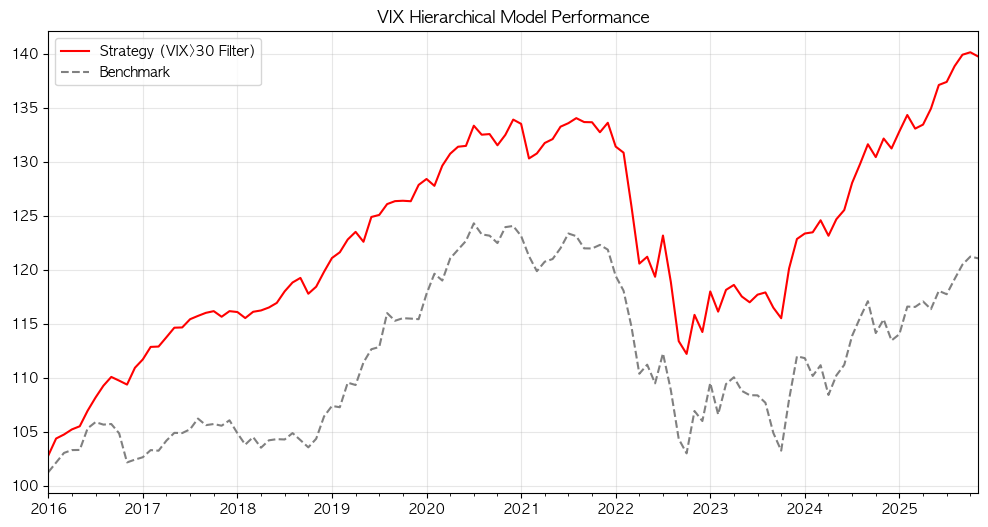

In [19]:
# [Cell 6] 백테스트 실행 (VIX 계층적 모델 + TLT 5% Mix)

# 1. 설정값 (레짐 4에 TLT 5% 포함)
REGIME_ALLOCATIONS_MIX = {
    1: {'SHYG': 0.85, 'IEF': 0.15, 'TLT': 0.0}, 
    2: {'SHYG': 0.60, 'IEF': 0.40, 'TLT': 0.0}, 
    3: {'SHYG': 0.35, 'IEF': 0.65, 'TLT': 0.0}, 
    4: {'SHYG': 0.15, 'IEF': 0.80, 'TLT': 0.05}, # TLT 5%
}
TRANSACTION_COSTS = {'SHYG': 0.003, 'IEF': 0.0015, 'TLT': 0.0015, 'AGG': 0.0015}

try:
    # 2. 수익률 데이터 준비 (이전과 동일)
    if 'monthly_returns' not in locals():
        # (데이터가 없다면 다시 만듦 - Cell 6 참조)
        tickers = ['IEF', 'AGG', 'TLT']
        f_start = PRICE_START_DATE_SNAPSHOT; f_end = END_DATE_SNAPSHOT
        data_others = yf.download(tickers, start=f_start, end=f_end)['Close']
        prices_others = data_others.resample('BM').last().ffill()
        shyg_df = shyg_prices_raw.to_frame('SHYG') if isinstance(shyg_prices_raw, pd.Series) else shyg_prices_raw
        all_prices = pd.concat([shyg_df, prices_others], axis=1)
        monthly_returns = all_prices.pct_change().dropna()

    # 3. 타깃 비중 및 백테스트
    regime_series = signals_hierarchical['Regime'].dropna()
    target_w = get_target_weights(regime_series, REGIME_ALLOCATIONS_MIX)
    
    strat_ret, strat_w = run_backtest(monthly_returns, target_w, TRANSACTION_COSTS)
    bench_ret = monthly_returns['AGG'].loc[strat_ret.index]

    # 4. 성과 출력
    def calc_stats(s):
        if len(s) < 1: return {}
        total = (1+s).prod()-1
        cagr = (1+total)**(1/(len(s)/12))-1
        mdd = ((1+s).cumprod() / (1+s).cumprod().expanding().max() - 1).min()
        sharpe = (s.mean()/s.std())*np.sqrt(12) if s.std()!=0 else 0
        return {'CAGR': cagr, 'MDD': mdd, 'Sharpe': sharpe}

    stats_df = pd.DataFrame({
        'Hierarchical (VIX Filter)': calc_stats(strat_ret),
        'Benchmark (AGG)': calc_stats(bench_ret)
    })
    
    print("\n" + "="*40)
    print("    <<< VIX 계층적 모델 성과 요약 >>>")
    print("="*40)
    print(stats_df.applymap(lambda x: f"{x:.2%}"))

    # 5. 그래프
    plt.figure(figsize=(12, 6))
    ((1+strat_ret).cumprod()*100).plot(label='Strategy (VIX>30 Filter)', color='red')
    ((1+bench_ret).cumprod()*100).plot(label='Benchmark', color='gray', linestyle='--')
    plt.title('VIX Hierarchical Model Performance')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error: {e}")
    import traceback; traceback.print_exc()

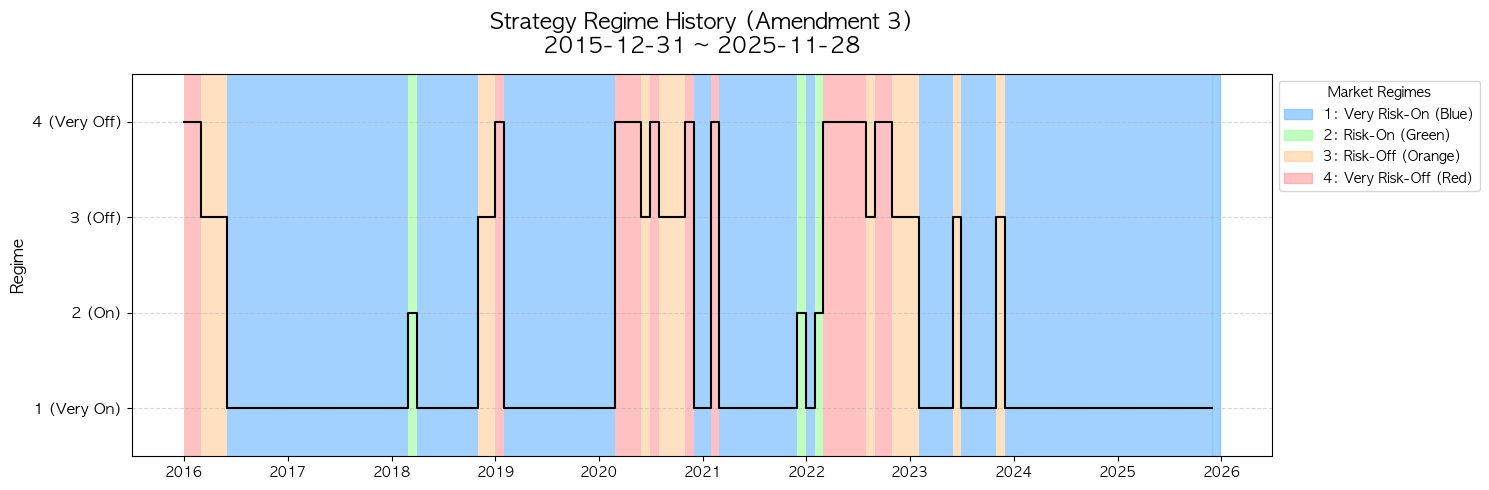


      <<< 레짐별 기간 분포 >>>
Regime 1:  86개월 (71.7%) - 1: Very Risk-On (Blue)
Regime 2:   3개월 (2.5%) - 2: Risk-On (Green)
Regime 3:  15개월 (12.5%) - 3: Risk-Off (Orange)
Regime 4:  16개월 (13.3%) - 4: Very Risk-Off (Red)


In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# [Cell 8] 월별 레짐 타임라인 시각화

if 'regime_series' in locals():
    
    # 1. 시각화 설정
    fig, ax = plt.subplots(figsize=(15, 5))
    
    # 레짐별 색상 및 라벨 정의
    regime_props = {
        1: {'color': '#66b3ff', 'label': '1: Very Risk-On (Blue)'},   # 파랑
        2: {'color': '#99ff99', 'label': '2: Risk-On (Green)'},       # 초록
        3: {'color': '#ffcc99', 'label': '3: Risk-Off (Orange)'},     # 주황
        4: {'color': '#ff9999', 'label': '4: Very Risk-Off (Red)'}    # 빨강
    }
    
    # 2. 레짐 타임라인 그리기 (배경색 채우기)
    # (t 시점의 시그널은 t ~ t+1 기간의 포지션을 결정하므로 해당 구간을 칠합니다)
    dates = regime_series.index
    
    for i in range(len(dates) - 1):
        current_date = dates[i]
        next_date = dates[i+1]
        regime = int(regime_series.iloc[i])
        
        # 해당 구간을 레짐 색상으로 칠하기
        ax.axvspan(current_date, next_date, 
                   color=regime_props[regime]['color'], 
                   alpha=0.6, # 투명도
                   ec=None)   # 테두리 없음

    # 마지막 구간 처리 (한 달 더 연장)
    last_date = dates[-1]
    extended_date = last_date + pd.DateOffset(months=1)
    last_regime = int(regime_series.iloc[-1])
    ax.axvspan(last_date, extended_date, color=regime_props[last_regime]['color'], alpha=0.6)

    # 3. 레짐 스텝 차트 (선 그래프) 추가
    ax.step(regime_series.index, regime_series, where='post', color='black', linewidth=1.5, label='Regime Level')
    
    # 4. 차트 꾸미기
    ax.set_title(f'Strategy Regime History (Amendment 3)\n{dates[0].date()} ~ {dates[-1].date()}', fontsize=16, pad=15)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(['1 (Very On)', '2 (On)', '3 (Off)', '4 (Very Off)'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Regime', fontsize=12)
    ax.set_ylim(0.5, 4.5)
    
    # X축 날짜 포맷
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 범례 생성 (색상 설명)
    patches = [plt.Rectangle((0,0),1,1, color=props['color'], alpha=0.6) for props in regime_props.values()]
    labels = [props['label'] for props in regime_props.values()]
    ax.legend(patches, labels, loc='upper left', bbox_to_anchor=(1, 1), title="Market Regimes")

    plt.tight_layout()
    plt.savefig('regime_timeline.png') # 이미지 저장
    plt.show()
    
    # --- 5. 레짐 분포 통계 ---
    print("\n" + "="*40)
    print("      <<< 레짐별 기간 분포 >>>")
    print("="*40)
    counts = regime_series.value_counts().sort_index()
    total_months = len(regime_series)
    
    for r in range(1, 5):
        count = counts.get(r, 0)
        ratio = count / total_months
        print(f"Regime {r}: {count:3d}개월 ({ratio:.1%}) - {regime_props[r]['label']}")

else:
    print("오류: 'regime_series' 데이터가 없습니다. [Cell 6]를 먼저 실행해주세요.")

In [21]:
# [Cell 7] 스트레스 구간 성과 분석 (VIX 계층적 모델)

if 'strat_ret' in locals() and 'bench_ret' in locals():

    # --- 1. 분석 함수 정의 ---
    def analyze_stress_period(strategy, benchmark, start_date, end_date, period_name):
        # 해당 기간 데이터 슬라이싱
        strat_slice = strategy.loc[start_date:end_date]
        bench_slice = benchmark.loc[start_date:end_date]
        
        if strat_slice.empty:
            return {
                'Period': period_name,
                'Strategy Return': 0.0, 'Strategy MDD': 0.0,
                'Benchmark Return': 0.0, 'Benchmark MDD': 0.0
            }

        # 누적 수익률
        strat_cum = (1 + strat_slice).prod() - 1
        bench_cum = (1 + bench_slice).prod() - 1
        
        # MDD (해당 구간 내에서의 고점 대비 하락)
        def get_mdd(s):
            cum = (1 + s).cumprod()
            dd = (cum / cum.expanding().max() - 1).min()
            return dd

        return {
            'Period': period_name,
            'Strategy Return': strat_cum,
            'Strategy MDD': get_mdd(strat_slice),
            'Benchmark Return': bench_cum,
            'Benchmark MDD': get_mdd(bench_slice)
        }

    # --- 2. 스트레스 구간 설정 ---
    stress_periods = [
        ('COVID-19 Crash', '2020-02-01', '2020-04-30'),
        ('2022 Rate Hike', '2022-01-01', '2022-12-31')
    ]

    # --- 3. 분석 실행 및 결과 출력 ---
    results = []
    for name, start, end in stress_periods:
        res = analyze_stress_period(strat_ret, bench_ret, start, end, name)
        results.append(res)

    stress_df = pd.DataFrame(results).set_index('Period')
    
    # 보기 좋게 포맷팅
    print("\n" + "="*55)
    print("      <<< VIX 계층적 모델: 스트레스 구간 성과 >>>")
    print("="*55)
    print(stress_df.applymap(lambda x: f"{x:.2%}"))

    # --- 4. (참고) 해당 구간의 VIX 평균 확인 ---
    # VIX가 실제로 높았는지 확인하기 위함
    if 'signals_hierarchical' in locals():
        print("\n[참고] 위기 구간 평균 VIX 지수:")
        for name, start, end in stress_periods:
            # signals_hierarchical의 인덱스는 월말이므로 해당 기간 포함되는지 확인
            period_data = signals_hierarchical.loc[start:end]
            if not period_data.empty:
                avg_vix = period_data['VIX'].mean()
                max_vix = period_data['VIX'].max()
                triggered_months = len(period_data[period_data['VIX'] > 30])
                print(f"- {name}: 평균 {avg_vix:.1f}, 최대 {max_vix:.1f} (VIX>30 발동: {triggered_months}개월)")

else:
    print("오류: 'strat_ret' 데이터가 없습니다. [Cell 6]을 먼저 실행해주세요.")


      <<< VIX 계층적 모델: 스트레스 구간 성과 >>>
               Strategy Return Strategy MDD Benchmark Return Benchmark MDD
Period                                                                    
COVID-19 Crash           1.82%        0.00%            2.79%        -0.53%
2022 Rate Hike         -14.50%      -14.61%          -13.02%       -13.75%

[참고] 위기 구간 평균 VIX 지수:
- COVID-19 Crash: 평균 42.6, 최대 53.5 (VIX>30 발동: 3개월)
- 2022 Rate Hike: 평균 25.9, 최대 33.4 (VIX>30 발동: 3개월)


In [26]:
import pandas as pd
import numpy as np

# [Cell 11] 최종 전략(VIX 필터 + TLT 5%) 엑셀 내보내기

# 1. 전략 설정 (VIX 계층적 모델용)
REGIME_ALLOCATIONS_FINAL = {
    1: {'SHYG': 0.85, 'IEF': 0.15, 'TLT': 0.0}, 
    2: {'SHYG': 0.60, 'IEF': 0.40, 'TLT': 0.0}, 
    3: {'SHYG': 0.35, 'IEF': 0.65, 'TLT': 0.0}, 
    4: {'SHYG': 0.15, 'IEF': 0.80, 'TLT': 0.05}, # (수정안 4: TLT 5% 포함)
}
TRANSACTION_COSTS = {'SHYG': 0.003, 'IEF': 0.0015, 'TLT': 0.0015, 'AGG': 0.0015}

# 데이터가 준비되었는지 확인
if 'oas_series_bm' in locals() and 'shyg_prices_raw' in locals() and 'vix_series_bm' in locals():
    try:
        print("1. 수익률 데이터 준비 중...")
        # 전체 자산 가격 데이터 병합 (수익률 계산용)
        # (Cell 6에서 이미 로드된 data_others가 있다면 재사용, 없으면 다시 로드)
        if 'prices_others' not in locals():
            tickers = ['IEF', 'AGG', 'TLT']
            # 기간은 Cell 4 기준
            data_others = yf.download(tickers, start=PRICE_START_DATE_SNAPSHOT, end=END_DATE_SNAPSHOT)['Close']
            prices_others = data_others.resample('BM').last().ffill()
        
        shyg_df = shyg_prices_raw.to_frame('SHYG') if isinstance(shyg_prices_raw, pd.Series) else shyg_prices_raw
        all_prices = pd.concat([shyg_df, prices_others], axis=1)
        monthly_returns = all_prices.pct_change().dropna()

        print("2. VIX 계층적 레짐 계산 중...")
        # 시그널 계산
        signals_final = calculate_hierarchical_signals(
            oas_series_bm, shyg_prices_raw, vix_series_bm, 
            oas_z_window=24, level_window=12
        )
        # 레짐 결정 (VIX > 30 필터 적용)
        regime_series = signals_final.apply(define_hierarchical_regime, axis=1).dropna()

        print("3. 백테스트 수행 중...")
        # 타깃 비중 생성
        target_w = get_target_weights(regime_series, REGIME_ALLOCATIONS_FINAL)
        
        # 백테스트 (수익률 및 실제 비중 산출)
        strat_ret, strat_w = run_backtest(monthly_returns, target_w, TRANSACTION_COSTS)
        bench_ret = monthly_returns['AGG'].loc[strat_ret.index]

        print("4. 엑셀 데이터 생성 중...")
        # 데이터 병합 (인덱스 교집합)
        common_idx = strat_ret.index.intersection(regime_series.index)
        
        excel_df = pd.DataFrame(index=common_idx)
        excel_df.index.name = 'Date'
        
        # [Regime]
        # 시그널(t) -> 수익률(t+1) 관계이므로, 해당 월 수익률의 원인이 된 레짐(전월 시그널)을 표시
        excel_df['Regime'] = regime_series.shift(1).loc[common_idx]
        
        # [Weights]
        # strat_w는 이미 shift 되어 해당 월 수익률에 기여한 비중임
        excel_df['SHYG_Weight'] = strat_w.loc[common_idx, 'SHYG']
        excel_df['IEF_Weight'] = strat_w.loc[common_idx, 'IEF']
        excel_df['TLT_Weight'] = strat_w.loc[common_idx, 'TLT'] # TLT 추가
        
        # [Returns]
        excel_df['Net_Return'] = strat_ret.loc[common_idx]
        excel_df['Benchmark_Return'] = bench_ret.loc[common_idx]
        
        # [VIX & OAS] (참고용으로 원본 지표도 추가하면 분석에 좋습니다)
        excel_df['VIX_Close'] = vix_series_bm.shift(1).loc[common_idx] # 전월 말 VIX
        
        # NaN 제거 및 포맷팅
        excel_df = excel_df.dropna()
        excel_df['Regime'] = excel_df['Regime'].astype(int)

        # 5. 파일 저장
        file_name = 'strategy_VIX_TLT_mix_report.xlsx'
        excel_df.to_excel(file_name)
        
        print(f"\n[성공] '{file_name}' 파일이 생성되었습니다.")
        
        # 미리보기
        print("\n--- [미리보기] 2020년 코로나 구간 (VIX 필터 작동 확인) ---")
        # 2020년 2월~5월 데이터 출력
        display_cols = ['Regime', 'SHYG_Weight', 'IEF_Weight', 'TLT_Weight', 'Net_Return', 'VIX_Close']
        preview = excel_df.loc['2020-01-01':'2020-06-30', display_cols]
        
        # 퍼센트 포맷팅 (화면 출력용)
        pd.options.display.float_format = '{:.2%}'.format
        # VIX와 Regime은 숫자 그대로
        preview_fmt = preview.copy()
        preview_fmt['VIX_Close'] = preview['VIX_Close'].apply(lambda x: f"{x:.2f}")
        preview_fmt['Regime'] = preview['Regime'].astype(str)
        
        print(preview_fmt)
        pd.reset_option('display.float_format')

    except Exception as e:
        print(f"오류 발생: {e}")
        import traceback; traceback.print_exc()
else:
    print("오류: 필수 데이터가 로드되지 않았습니다. [Cell 4]부터 순서대로 실행해주세요.")

1. 수익률 데이터 준비 중...
2. VIX 계층적 레짐 계산 중...
Step 3: 계층적 시그널 계산 중...
계층적 시그널(OAS, PPR, VIX) 생성 완료.
3. 백테스트 수행 중...
Step 4: 타깃 비중 생성 중...
Step: 백테스트 실행 중...
4. 엑셀 데이터 생성 중...

[성공] 'strategy_VIX_TLT_mix_report.xlsx' 파일이 생성되었습니다.

--- [미리보기] 2020년 코로나 구간 (VIX 필터 작동 확인) ---
           Regime  SHYG_Weight  IEF_Weight  TLT_Weight  Net_Return VIX_Close
Date                                                                        
2020-01-31      1       85.00%      15.00%       0.00%       0.43%     13.78
2020-02-28      1       85.00%      15.00%       0.00%      -0.49%     18.84
2020-03-31      4       15.00%      80.00%       5.00%       1.46%     40.11
2020-04-30      4       15.00%      80.00%       5.00%       0.86%     53.54
2020-05-29      4       15.00%      80.00%       5.00%       0.50%     34.15
2020-06-30      3       35.00%      65.00%       0.00%       0.06%     27.51


In [23]:
import numpy as np
import pandas as pd

# [Cell 12] 상세 성과 지표 계산 (CAGR, 총수익, 변동성, MDD, Sharpe)

if 'strat_ret' in locals() and 'bench_ret' in locals():

    def calculate_detailed_metrics(returns_series):
        """
        월별 수익률 시리즈를 받아 5가지 핵심 지표를 계산하는 함수
        (무위험 수익률 0% 가정)
        """
        if len(returns_series) < 1: return {}
        
        # 1. 총수익 (Total Return)
        total_return = (1 + returns_series).prod() - 1
        
        # 2. CAGR (연평균 성장률)
        years = len(returns_series) / 12
        cagr = (1 + total_return) ** (1 / years) - 1
        
        # 3. 변동성 (Volatility) - 연환산
        volatility = returns_series.std() * np.sqrt(12)
        
        # 4. MDD (최대 낙폭)
        cum_ret = (1 + returns_series).cumprod()
        peak = cum_ret.expanding(min_periods=1).max()
        drawdown = (cum_ret - peak) / peak
        mdd = drawdown.min()
        
        # 5. Sharpe Ratio (샤프 지수) - 연환산
        if returns_series.std() == 0:
            sharpe = 0
        else:
            sharpe = (returns_series.mean() / returns_series.std()) * np.sqrt(12)
        
        return {
            'CAGR (%)': cagr * 100,
            '총수익 (%)': total_return * 100,
            '변동성 (%)': volatility * 100,
            'MDD (%)': mdd * 100,
            'Sharpe': sharpe
        }

    # --- 지표 산출 ---
    metrics_strategy = calculate_detailed_metrics(strat_ret)
    metrics_benchmark = calculate_detailed_metrics(bench_ret)
    
    # 결과 데이터프레임 생성
    df_performance = pd.DataFrame({
        'Strategy (VIX Filter)': metrics_strategy,
        'Benchmark (AGG)': metrics_benchmark
    })
    
    # --- 출력 ---
    print("\n" + "="*50)
    print("      <<< 전략 상세 성과 분석 >>>")
    print("="*50)
    # 소수점 2자리까지 깔끔하게 출력
    print(df_performance.applymap(lambda x: f"{x:.2f}"))
    
else:
    print("오류: 'strat_ret' 데이터가 없습니다. [Cell 6]를 먼저 실행하여 백테스트를 완료해주세요.")


      <<< 전략 상세 성과 분석 >>>
         Strategy (VIX Filter) Benchmark (AGG)
CAGR (%)                  3.43            1.94
총수익 (%)                  39.73           21.05
변동성 (%)                   4.54            5.15
MDD (%)                 -16.29          -17.13
Sharpe                    0.77            0.40


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# [Cell 13] 최종 스냅샷 도넛 차트 시각화

if 'target_allocation' in locals() and 'latest_regime' in locals():
    
    # 1. 데이터 준비
    # 0%인 자산은 제외하고 시각화 (깔끔하게 보기 위함)
    plot_data = {k: v for k, v in target_allocation.items() if v > 0}
    labels = list(plot_data.keys())
    sizes = list(plot_data.values())
    
    # 2. 색상 설정
    # 레짐별 색상 (중앙 원)
    regime_color_map = {
        1: '#66b3ff', # 파랑 (Very Risk-On)
        2: '#99ff99', # 초록 (Risk-On)
        3: '#ffcc99', # 주황 (Risk-Off)
        4: '#ff9999'  # 빨강 (Very Risk-Off)
    }
    current_regime_color = regime_color_map.get(latest_regime, 'lightgray')
    
    # 자산별 색상 (바깥 링) - 파스텔 톤
    # SHYG(위험): 보라/파랑 계열, IEF/TLT(안전): 초록/청록 계열 등으로 구분 추천
    # 여기서는 자동으로 예쁜 색상을 할당합니다.
    asset_colors = sns.color_palette('Pastel2', len(labels))
    
    # 3. 차트 그리기
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # (1) 바깥쪽 링 (자산 배분)
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct='%1.0f%%', 
        startangle=90, 
        colors=asset_colors, 
        pctdistance=0.85, # 퍼센트 텍스트 위치
        wedgeprops=dict(width=0.3, edgecolor='w', linewidth=2) # 도넛 두께 및 테두리
    )
    
    # 텍스트 스타일링
    for text in texts:
        text.set_fontsize(12)
        text.set_fontweight('bold')
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_color('black')

    # (2) 안쪽 원 (레짐 표시)
    # 도넛 구멍(0.7)보다 약간 작은 원(0.65)을 그려서 흰색 테두리 효과를 줌
    centre_circle = plt.Circle((0,0), 0.68, fc='white') # 흰색 경계선 역할
    fig.gca().add_artist(centre_circle)
    
    inner_circle = plt.Circle((0,0), 0.65, fc=current_regime_color) # 레짐 색상
    fig.gca().add_artist(inner_circle)
    
    # (3) 중앙 텍스트 (Regime)
    ax.text(0, 0, f'Regime\n{int(latest_regime)}', 
            ha='center', va='center', 
            fontsize=24, fontweight='bold', color='black')
    
    # 4. 타이틀 및 마무리
    plt.title(f'Current Strategy Allocation (VIX Filter)\nAs of {latest_date.strftime("%Y-%m-%d")}', 
              fontsize=15, pad=20)
    
    ax.axis('equal')  # 원형 유지
    plt.tight_layout()
    
    # 저장 및 출력
    plt.savefig('final_snapshot_donut.png', dpi=300)
    print(f"현재 레짐: {int(latest_regime)} | 자산배분: {plot_data}")
    plt.show()

else:
    print("오류: 시각화할 데이터가 없습니다. [Cell 6] 또는 [Cell 11]을 먼저 실행해주세요.")

오류: 시각화할 데이터가 없습니다. [Cell 6] 또는 [Cell 11]을 먼저 실행해주세요.
